In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from src.data_preparation import preprocessing_for_eda

### Данные об аниме

In [2]:
df_anime = pd.read_csv('anime_dataset/anime.csv')
df_anime

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


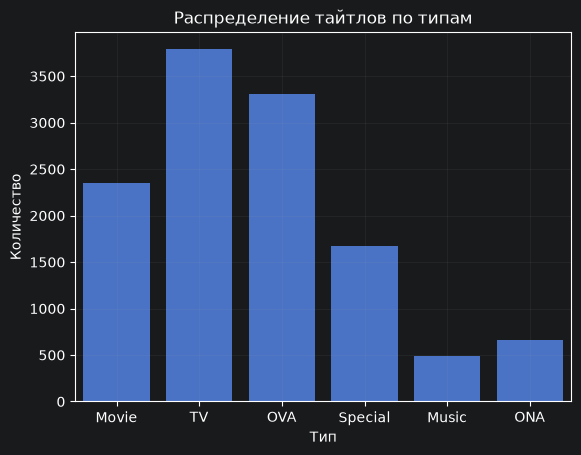

In [3]:
sns.countplot(data=df_anime, x='type')
plt.title('Распределение тайтлов по типам')
plt.xlabel('Тип')
plt.ylabel('Количество')
plt.grid(alpha=0.1)
plt.show()

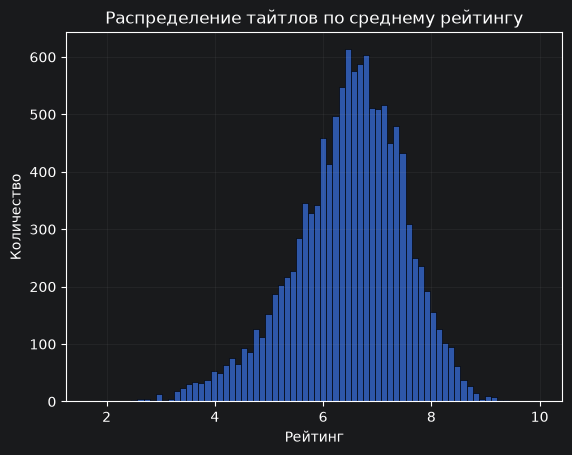

In [4]:
sns.histplot(data=df_anime, x='rating')
plt.title('Распределение тайтлов по среднему рейтингу')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.grid(alpha=0.1)
plt.show()

In [5]:
print(f'Средний рейтинг тайтлов: {df_anime.rating.mean():.2f}')
print(f'Медианный рейтинг тайтлов: {df_anime.rating.median():.2f}')

Средний рейтинг тайтлов: 6.47
Медианный рейтинг тайтлов: 6.57


Большинство аниме имеет средний рейтинг в диапазоне от 5 до 8 баллов. Распределение близко к нормальному, имеет небольшую положительную асимметрию, что свидетельствует о преобладании аниме с относительно высокими пользовательскими оценками.

### Данные об оценках пользователей

In [6]:
df_rating = pd.read_csv('anime_dataset/rating.csv')
df_rating

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1
...,...,...,...
7813732,73515,16512,7
7813733,73515,17187,9
7813734,73515,22145,10
7813735,73516,790,9


In [7]:
df_only_rated = df_rating[df_rating['rating'] != -1]
print(f'Общее количество просмотров всех тайтлов: {len(df_rating)}')
print(f'Доля оцененных при просмотре тайтлов: {(len(df_only_rated)/len(df_rating))*100:.2f}%')

Общее количество просмотров всех тайтлов: 7813737
Доля оцененных при просмотре тайтлов: 81.10%


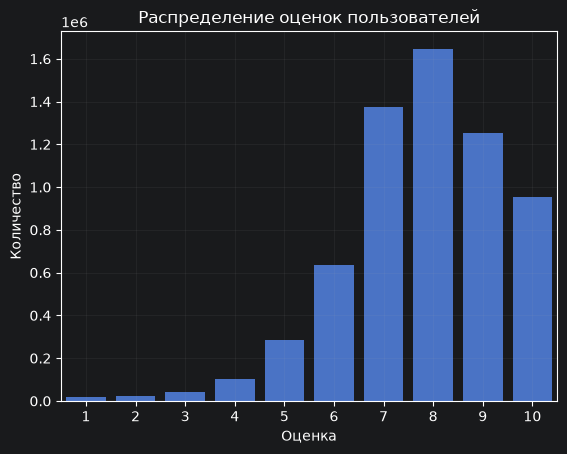

In [8]:
sns.countplot(data=df_only_rated, x='rating')
plt.title('Распределение оценок пользователей')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.grid(alpha=0.1)
plt.show()

Распределение оценок пользователей сильно смещено в сторону более высоких значений. Большинство оценок находятся в диапазоне от 6 до 10 баллов.

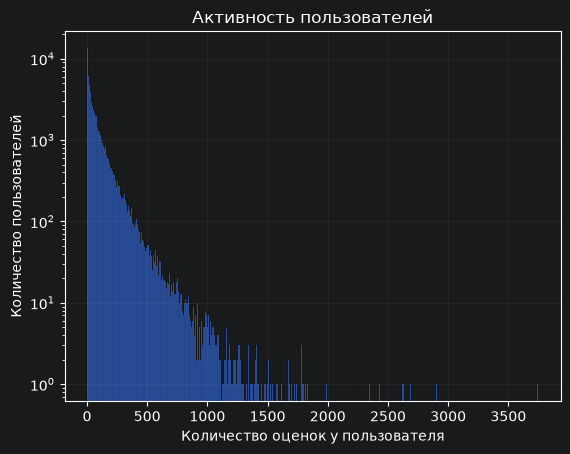

In [9]:
user_activity = (df_only_rated.groupby('user_id').size())

sns.histplot(user_activity, log=True)
plt.title('Активность пользователей')
plt.xlabel('Количество оценок у пользователя')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.1)
plt.show()

Большинство пользователей, по количеству своих оценок находятся в диапазоне от 0 до 500 оценок на пользователя. При этом встречается небольшое число пользователей, количество оценок у которых значительно выше, вплоть по 4 000 оценок на пользователя

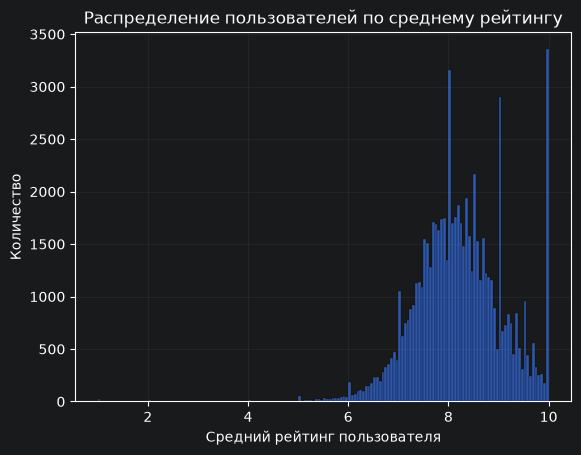

In [10]:
user_rating_mean = df_only_rated.groupby('user_id').rating.mean()
sns.histplot(user_rating_mean)
plt.title('Распределение пользователей по среднему рейтингу')
plt.xlabel('Средний рейтинг пользователя')
plt.ylabel('Количество')
plt.grid(alpha=0.1)
plt.show()

In [11]:
print(f'Среднее значение оценок пользователей: {user_rating_mean.mean():.2f}')
print(f'Медианное значение оценок пользователей: {user_rating_mean.median():.2f}')

Среднее значение оценок пользователей: 8.23
Медианное значение оценок пользователей: 8.19


Большинство пользователей, по среднему рейтингу находятся в диапазоне от 7 до 10 баллов. Это показывает что, пользователям свойственно ставить высокие оценки, что, вероятно, вызвано тем, что пользователи чаще ставят оценки тем тайтлам, которые им понравились. Значительно число тех пользователей, которые проставляют исключительно максимальные оценки.

### Объединенные данные

In [12]:
df = preprocessing_for_eda(df_anime, df_rating)
df

,user_id,anime_id,rating,name,genre,type,episodes,mean_rating_anime,members
0,1,20,-1,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220,7.81,683297
1,1,24,-1,School Rumble,"Comedy, Romance, School, Shounen",TV,26,8.06,178553
2,1,79,-1,Shuffle!,"Comedy, Drama, Ecchi, Fantasy, Harem, Magic, R...",TV,24,7.31,158772
3,1,226,-1,Elfen Lied,"Action, Drama, Horror, Psychological, Romance,...",TV,13,7.85,623511
4,1,241,-1,Girls Bravo: First Season,"Comedy, Ecchi, Fantasy, Harem, Romance, School",TV,11,6.69,84395
...,...,...,...,...,...,...,...,...,...
7813722,73515,16512,7,Devil Survivor 2 The Animation,"Action, Demons, Supernatural",TV,13,7.06,101266
7813723,73515,17187,9,Ghost in the Shell: Arise - Border:1 Ghost Pain,"Mecha, Police, Psychological, Sci-Fi",Movie,1,7.64,31747
7813724,73515,22145,10,Kuroshitsuji: Book of Circus,"Comedy, Demons, Fantasy, Historical, Shounen, ...",TV,10,8.37,122895
7813725,73516,790,9,Ergo Proxy,"Mystery, Psychological, Sci-Fi",TV,23,8.03,265005


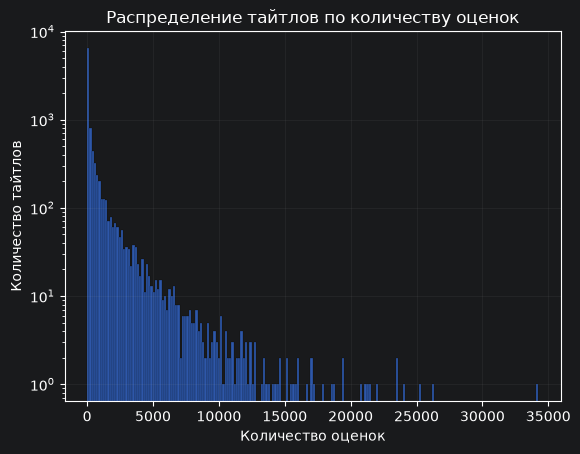

In [13]:
df_only_rated = df[df['rating'] != -1]
sns.histplot(df_only_rated.groupby('anime_id').rating.count(), log=True)
plt.title('Распределение тайтлов по количеству оценок')
plt.xlabel('Количество оценок')
plt.ylabel('Количество тайтлов')
plt.grid(alpha=0.1)
plt.show()

Распределение тайтлов по количеству оценок показывает что, для большей части аниме оценки ставились не более 5 000 раз, однако встречаются отдельные аниме с большим количеством оценок, вплоть до 35 000

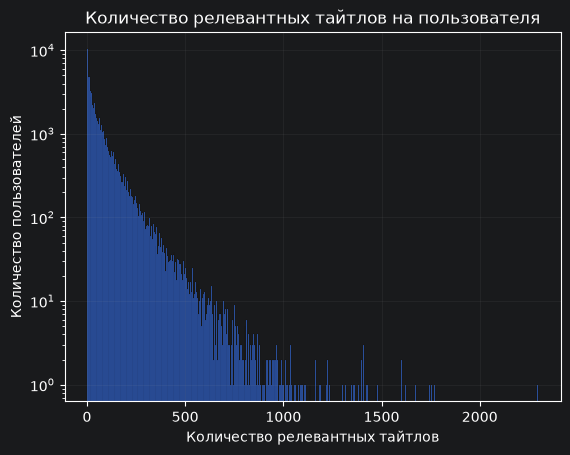

In [14]:
relevant_counts = df_only_rated[df_only_rated['rating'] >= 7].groupby('user_id').size()

sns.histplot(relevant_counts, log=True)
plt.title('Количество релевантных тайтлов на пользователя')
plt.xlabel('Количество релевантных тайтлов')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.1)
plt.show()

Для большей части пользователей количество релевантных тайтлов (с оценкой выше 7) находится в пределах от 0 до 500

In [15]:
sparsity = 1 - (len(df_rating) / (df_anime.anime_id.nunique() * df_rating.user_id.nunique()))
print(f'Процент незаполненности матрицы «пользователи-тайтлы»: {(sparsity * 100):.2f}%')

Процент незаполненности матрицы «пользователи-тайтлы»: 99.14%


Матрица "пользователь-тайтл" является крайне разреженной, что может сказываться на качестве работы модели SVD

### Топы по тайтлам

In [16]:
print('Топ-10 самых просматриваемых тайтлов')
df_anime.sort_values('members' ,ascending=False).iloc[:10, [0,1,6]]

Топ-10 самых просматриваемых тайтлов


,anime_id,name,members
40,1535,Death Note,1013917
86,16498,Shingeki no Kyojin,896229
804,11757,Sword Art Online,893100
1,5114,Fullmetal Alchemist: Brotherhood,793665
159,6547,Angel Beats!,717796
19,1575,Code Geass: Hangyaku no Lelouch,715151
841,20,Naruto,683297
3,9253,Steins;Gate,673572
445,10620,Mirai Nikki (TV),657190
131,4224,Toradora!,633817


In [17]:
print('Топ-10 тайтлов с самым высоким рейтингом')
df_anime[df_anime['members'] > df_anime['members'].quantile(0.5)].sort_values('rating', ascending=False).iloc[:10, [0,1,5]]

Топ-10 тайтлов с самым высоким рейтингом


,anime_id,name,rating
0,32281,Kimi no Na wa.,9.37
1,5114,Fullmetal Alchemist: Brotherhood,9.26
2,28977,Gintama°,9.25
3,9253,Steins;Gate,9.17
4,9969,Gintama&#039;,9.16
5,32935,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,9.15
6,11061,Hunter x Hunter (2011),9.13
7,820,Ginga Eiyuu Densetsu,9.11
9,15417,Gintama&#039;: Enchousen,9.11
8,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,9.10


In [18]:
print('Топ-10 тайтлов с самым большим количеством оценок')
df_only_rated.groupby('name').size().sort_values(ascending=False).head(10)

Топ-10 тайтлов с самым большим количеством оценок


name
Death Note                            34226
Sword Art Online                      26310
Shingeki no Kyojin                    25289
Code Geass: Hangyaku no Lelouch       24126
Angel Beats!                          23565
Elfen Lied                            23528
Naruto                                22071
Fullmetal Alchemist: Brotherhood      21494
Fullmetal Alchemist                   21332
Code Geass: Hangyaku no Lelouch R2    21124
dtype: int64

Ожидаемо, топ тайтлов по просмотрам значительно пересекается с топом по количеству оценок. Стоить отметить, что часть наиболее популярных тайтлов также входит в число наиболее высоко оценённых, что может свидетельствовать о связи между популярностью и оценками пользователей.